# 03 — Clasificación de lesiones con EfficientNet-B0

**Proyecto:** Skin Lesion Analysis  
**Repositorio:** https://github.com/Jesusrodriguezf90/skin-lesion-analysis  
**Fase:** Entrenamiento del modelo de clasificación

---

Este notebook entrena un EfficientNet-B0 con transfer learning sobre HAM10000
(ISIC 2018 Task 3) para clasificar lesiones cutáneas en 7 categorías clínicas.

Es la segunda etapa del pipeline: recibe la región segmentada por U-Net
y produce el diagnóstico clínico.

In [1]:
"""
Notebook: 03_classification.ipynb

Objetivo:
    Entrenar EfficientNet-B0 con transfer learning sobre HAM10000
    (ISIC 2018 Task 3, 10.015 imágenes) para clasificación multiclase
    de lesiones cutáneas en 7 categorías clínicas.

Decisiones de diseño:
    - Resolución de entrada: 256×256. Coherente con 02_segmentation.ipynb.
    - Desbalance de clases: ratio máximo 58.3x (NV vs DF). Se aborda con
      WeightedRandomSampler en el DataLoader — sobremuestrea las clases
      minoritarias en cada batch. Alternativa a weighted loss porque permite
      que el modelo vea más ejemplos reales de clases minoritarias en lugar
      de simplemente penalizar más sus errores.
    - Split: 80/20 con semilla fija (seed=42). Estratificado por clase para
      garantizar representación de todas las clases en validación.
    - Loss: CrossEntropyLoss con class_weights — doble estrategia contra
      el desbalance junto con WeightedRandomSampler.
    - Early stopping: paciencia=5 monitorizando F1 macro en validación.
      F1 macro es más informativo que accuracy con clases desbalanceadas.
    - Optimizer: AdamW lr=1e-4, weight_decay=1e-4.
    - Scheduler: ReduceLROnPlateau sobre F1 macro val.
    - Fine-tuning progresivo: primero se entrena solo el clasificador
      (encoder congelado, 5 épocas), luego se descongela todo el modelo.
      Estándar en transfer learning para evitar destruir los pesos
      preentrenados en las primeras épocas.

Dataset:
    ISIC 2018 Task 3 / HAM10000 — 10.015 imágenes + etiquetas (7 clases)
    https://challenge.isic-archive.com/data/#2018

Autor:   Jesús Rodríguez
Fecha:   2026-06-04
Versión: 1.0.0
"""

'\nNotebook: 03_classification.ipynb\n\nObjetivo:\n    Entrenar EfficientNet-B0 con transfer learning sobre HAM10000\n    (ISIC 2018 Task 3, 10.015 imágenes) para clasificación multiclase\n    de lesiones cutáneas en 7 categorías clínicas.\n\nDecisiones de diseño:\n    - Resolución de entrada: 256×256. Coherente con 02_segmentation.ipynb.\n    - Desbalance de clases: ratio máximo 58.3x (NV vs DF). Se aborda con\n      WeightedRandomSampler en el DataLoader — sobremuestrea las clases\n      minoritarias en cada batch. Alternativa a weighted loss porque permite\n      que el modelo vea más ejemplos reales de clases minoritarias en lugar\n      de simplemente penalizar más sus errores.\n    - Split: 80/20 con semilla fija (seed=42). Estratificado por clase para\n      garantizar representación de todas las clases en validación.\n    - Loss: CrossEntropyLoss con class_weights — doble estrategia contra\n      el desbalance junto con WeightedRandomSampler.\n    - Early stopping: paciencia=5 

## 1. Configuración del entorno

In [2]:
# Detección del entorno de ejecución (Kaggle vs local)
import os

IN_KAGGLE = os.path.exists("/kaggle/input")
print(f"Entorno detectado: {"Kaggle" if IN_KAGGLE else "local"}")

Entorno detectado: Kaggle


In [3]:
# Verificación del entorno y GPU disponible
import sys
import torch

print(f"Python  : {sys.version}")
print(f"PyTorch : {torch.__version__}")
print(f"CUDA    : {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"GPU     : {torch.cuda.get_device_name(0)}")
    print(f"VRAM    : {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB")

Python  : 3.12.13 (main, Mar  4 2026, 09:23:07) [GCC 11.4.0]
PyTorch : 2.10.0+cu128
CUDA    : True
GPU     : Tesla T4
VRAM    : 15.6 GB


## 2. Instalación de dependencias

In [4]:
# Instalación de dependencias de clasificación médica
%pip install timm albumentations -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.2/12.2 MB 76.9 MB/s eta 0:00:00:00:010:01
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
dask-cuda 26.2.0 requires cuda-core==0.3.*, but you have cuda-core 1.0.1 which is incompatible.
dask-cuda 26.2.0 requires numba-cuda<0.23.0,>=0.22.1, but you have numba-cuda 0.30.2 which is incompatible.
distributed-ucxx-cu12 0.48.0 requires numba-cuda[cu12]<0.23.0,>=0.22.1, but you have numba-cuda 0.30.2 which is incompatible.
cuml-cu12 26.2.0 requires numba<0.62.0,>=0.60.0, but you have numba 0.65.1 which is incompatible.
cuml-cu12 26.2.0 requires numba-cuda[cu12]<0.23.0,>=0.22.1, but you have numba-cuda 0.30.2 which is incompatible.
ucxx-cu12 0.48.0 requires numba-cuda[cu12]<0.23.0,>=0.22.1, but you have numba-cuda 0.30.2 which is incompatible.
cudf-cu12 26.2.1 requires numba<0.62.0,>=0.60.0, but you have numba 0.65.1 which

In [5]:
# Verificación de imports principales
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
from PIL import Image

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader, WeightedRandomSampler
from sklearn.model_selection import train_test_split
import timm
import albumentations as A
from albumentations.pytorch import ToTensorV2

print("Dependencias importadas correctamente")

Dependencias importadas correctamente


## 3. Reproducibilidad y configuración global

In [6]:
# Semilla global para reproducibilidad completa del experimento
SEED = 42

def set_seed(seed: int) -> None:
    """Fija la semilla en todos los generadores aleatorios del stack.

    Args:
        seed: Valor entero de la semilla.
    """
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark     = False

set_seed(SEED)
print(f"Semilla fijada: {SEED}")

Semilla fijada: 42


In [7]:
# Hiperparámetros del experimento — centralizados para facilitar ajustes
CFG = {
    "img_size"        : 256,
    "batch_size"      : 32,      # T4: 32 viable a 256×256 con EfficientNet-B0
    "num_workers"     : 2,
    "epochs_frozen"   : 5,       # épocas con encoder congelado
    "epochs_unfrozen" : 30,      # épocas con todo el modelo descongelado
    "lr_frozen"       : 1e-3,    # lr más alto cuando solo se entrena el head
    "lr_unfrozen"     : 1e-4,    # lr más bajo al descongelar el encoder
    "weight_decay"    : 1e-4,
    "val_split"       : 0.2,
    "patience"        : 5,
    "num_classes"     : 7,
    "model_name"      : "efficientnet_b0",
}

CLASES = ["MEL", "NV", "BCC", "AKIEC", "BKL", "DF", "VASC"]

NOMBRES_CLASES = {
    "MEL"  : "Melanoma",
    "NV"   : "Melanocytic nevus",
    "BCC"  : "Basal cell carcinoma",
    "AKIEC": "Actinic keratosis",
    "BKL"  : "Benign keratosis",
    "DF"   : "Dermatofibroma",
    "VASC" : "Vascular lesion",
}

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Dispositivo : {DEVICE}")
print(f"Config      : {CFG}")

Dispositivo : cuda
Config      : {'img_size': 256, 'batch_size': 32, 'num_workers': 2, 'epochs_frozen': 5, 'epochs_unfrozen': 30, 'lr_frozen': 0.001, 'lr_unfrozen': 0.0001, 'weight_decay': 0.0001, 'val_split': 0.2, 'patience': 5, 'num_classes': 7, 'model_name': 'efficientnet_b0'}


## 4. Definición de rutas

In [8]:
# Rutas del dataset — estructura consistente con notebooks anteriores
if IN_KAGGLE:
    DIR_INPUT  = Path("/kaggle/input/datasets/jesusrf1990/isic2018-skin-lesion")
    DIR_OUTPUT = Path("/kaggle/working")
else:
    DIR_INPUT  = Path("data/raw")
    DIR_OUTPUT = Path("data/processed")

# Task 3 — imágenes de clasificación (HAM10000)
DIR_IMAGENES_T3 = DIR_INPUT / "ISIC2018_Task3_Training_Input" / "ISIC2018_Task3_Training_Input"
RUTA_CSV        = DIR_INPUT / "ISIC2018_Task3_Training_GroundTruth.csv"

DIR_OUTPUT.mkdir(parents=True, exist_ok=True)

# Validación de existencia de las rutas antes de continuar
assert DIR_IMAGENES_T3.exists(), f"No se encontró el directorio de imágenes Task 3: {DIR_IMAGENES_T3}"
assert RUTA_CSV.exists(),        f"No se encontró el CSV de etiquetas: {RUTA_CSV}"

imagenes_t3 = sorted(DIR_IMAGENES_T3.glob("*.jpg"))
print(f"Imágenes Task 3 : {len(imagenes_t3)}")
print(f"CSV etiquetas   : {RUTA_CSV}")

Imágenes Task 3 : 10015
CSV etiquetas   : /kaggle/input/datasets/jesusrf1990/isic2018-skin-lesion/ISIC2018_Task3_Training_GroundTruth.csv


## 5. Carga y preparación del dataset

In [9]:
# Carga del CSV y construcción del DataFrame con rutas e índices de clase
df = pd.read_csv(RUTA_CSV)

# Convertir one-hot a índice de clase entero
df["label"] = df[CLASES].values.argmax(axis=1)
df["label_nombre"] = df["label"].map(dict(enumerate(CLASES)))

# Añadir ruta completa de cada imagen
df["ruta"] = df["image"].apply(lambda x: DIR_IMAGENES_T3 / f"{x}.jpg")

# Verificar que todas las imágenes existen en disco
n_faltantes = df["ruta"].apply(lambda p: not p.exists()).sum()
print(f"Imágenes faltantes: {n_faltantes}")

print(f"\nDistribución de clases:")
for i, clase in enumerate(CLASES):
    n = (df["label"] == i).sum()
    print(f"  {clase:<6} {NOMBRES_CLASES[clase]:<25} {n:>5}")

Imágenes faltantes: 0

Distribución de clases:
  MEL    Melanoma                   1113
  NV     Melanocytic nevus          6705
  BCC    Basal cell carcinoma        514
  AKIEC  Actinic keratosis           327
  BKL    Benign keratosis           1099
  DF     Dermatofibroma              115
  VASC   Vascular lesion             142


In [10]:
# Split estratificado 80/20 — garantiza representación de todas las clases
# en validación incluso con clases minoritarias (DF=115, VASC=142)
df_train, df_val = train_test_split(
    df,
    test_size    = CFG["val_split"],
    random_state = SEED,
    stratify     = df["label"],
)

df_train = df_train.reset_index(drop=True)
df_val   = df_val.reset_index(drop=True)

print("=" * 45)
print("SPLIT DEL DATASET")
print("=" * 45)
print(f"  Total       : {len(df)}")
print(f"  Entrenamiento: {len(df_train)}")
print(f"  Validación  : {len(df_val)}")
print("=" * 45)

SPLIT DEL DATASET
  Total       : 10015
  Entrenamiento: 8012
  Validación  : 2003


In [11]:
# WeightedRandomSampler — sobremuestrea clases minoritarias en cada batch
# Más efectivo que weighted loss sola con desbalance severo (58.3x)
# porque el modelo ve más ejemplos reales de DF y VASC en lugar de solo
# penalizar más sus errores
conteo_clases = np.bincount(df_train["label"].values)
pesos_clases  = 1.0 / conteo_clases
pesos_muestras = pesos_clases[df_train["label"].values]

sampler = WeightedRandomSampler(
    weights     = torch.tensor(pesos_muestras, dtype=torch.float),
    num_samples = len(df_train),
    replacement = True,
)

print("WeightedRandomSampler configurado")
print(f"  Pesos por clase: {dict(zip(CLASES, pesos_clases.round(4)))}")

WeightedRandomSampler configurado
  Pesos por clase: {'MEL': np.float64(0.0011), 'NV': np.float64(0.0002), 'BCC': np.float64(0.0024), 'AKIEC': np.float64(0.0038), 'BKL': np.float64(0.0011), 'DF': np.float64(0.0109), 'VASC': np.float64(0.0088)}


## 6. Dataset PyTorch y data augmentation

In [12]:
def get_transforms(img_size: int, train: bool) -> A.Compose:
    """Devuelve el pipeline de data augmentation para train o validación.

    Args:
        img_size: Resolución de salida (ancho = alto).
        train:    True para data augmentation, False para solo resize + normalización.

    Returns:
        Pipeline de Albumentations listo para aplicar.

    Notes:
        Normalización con media/std de ImageNet — EfficientNet-B0 fue
        preentrenado con estas estadísticas.
        ColorJitter incluido — el color es una feature diagnóstica crítica
        en dermatoscopía (marcadores de color asociados a estadios de melanoma).
    """
    if train:
        return A.Compose([
            A.Resize(img_size, img_size),
            A.HorizontalFlip(p=0.5),
            A.VerticalFlip(p=0.5),
            A.RandomRotate90(p=0.5),
            A.ShiftScaleRotate(shift_limit=0.1, scale_limit=0.2, rotate_limit=30, p=0.5),
            A.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2, hue=0.1, p=0.4),
            A.Normalize(mean=(0.485, 0.456, 0.406), std=(0.229, 0.224, 0.225)),
            ToTensorV2(),
        ])
    return A.Compose([
        A.Resize(img_size, img_size),
        A.Normalize(mean=(0.485, 0.456, 0.406), std=(0.229, 0.224, 0.225)),
        ToTensorV2(),
    ])

In [13]:
class HAM10000Dataset(Dataset):
    """Dataset PyTorch para clasificación multiclase sobre HAM10000.

    Args:
        df:        DataFrame con columnas "ruta" y "label".
        transform: Pipeline de Albumentations a aplicar.

    Notes:
        Las imágenes se cargan en RGB directamente desde disco.
        No se usa caché en memoria — con 10.015 imágenes a 256×256
        ocuparía ~2GB de RAM innecesariamente.
    """

    def __init__(self, df: pd.DataFrame, transform=None):
        self.df        = df.reset_index(drop=True)
        self.transform = transform

    def __len__(self) -> int:
        return len(self.df)

    def __getitem__(self, idx: int) -> tuple:
        ruta  = self.df.loc[idx, "ruta"]
        label = self.df.loc[idx, "label"]

        img = np.array(Image.open(ruta).convert("RGB"))

        if self.transform:
            img = self.transform(image=img)["image"]

        return img, torch.tensor(label, dtype=torch.long)

In [14]:
# Construcción de datasets y DataLoaders
ds_train = HAM10000Dataset(df_train, get_transforms(CFG["img_size"], train=True))
ds_val   = HAM10000Dataset(df_val,   get_transforms(CFG["img_size"], train=False))

# Train usa sampler en lugar de shuffle — son mutuamente excluyentes
dl_train = DataLoader(
    ds_train,
    batch_size  = CFG["batch_size"],
    sampler     = sampler,
    num_workers = CFG["num_workers"],
    pin_memory  = True,
)
dl_val = DataLoader(
    ds_val,
    batch_size  = CFG["batch_size"],
    shuffle     = False,
    num_workers = CFG["num_workers"],
    pin_memory  = True,
)

print(f"Batches train : {len(dl_train)}")
print(f"Batches val   : {len(dl_val)}")

Batches train : 251
Batches val   : 63


/usr/local/lib/python3.12/dist-packages/albumentations/core/validation.py:114: UserWarning: ShiftScaleRotate is a special case of Affine transform. Please use Affine transform instead.
  original_init(self, **validated_kwargs)


## 7. Modelo

In [15]:
# EfficientNet-B0 preentrenado en ImageNet cargado con timm
# num_classes=7 reemplaza el clasificador original por uno de 7 clases
model = timm.create_model(
    CFG["model_name"],
    pretrained  = True,
    num_classes = CFG["num_classes"]
).to(DEVICE)

# Conteo de parámetros
total_params     = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)

print("=" * 45)
print("MODELO — EfficientNet-B0")
print("=" * 45)
print(f"  Parámetros totales    : {total_params:,}")
print(f"  Parámetros entrenables: {trainable_params:,}")
print("=" * 45)

model.safetensors:   0%|          | 0.00/21.4M [00:00<?, ?B/s]

MODELO — EfficientNet-B0
  Parámetros totales    : 4,016,515
  Parámetros entrenables: 4,016,515


In [16]:
# Congelar el encoder — solo se entrena el clasificador en las primeras épocas
# Evita destruir los pesos preentrenados de ImageNet con lr alto
# en las primeras épocas cuando el clasificador aún genera gradientes erráticos
def congelar_encoder(model: nn.Module) -> None:
    """Congela todos los parámetros excepto el clasificador final.

    Args:
        model: EfficientNet-B0 cargado con timm.
    """
    for name, param in model.named_parameters():
        if "classifier" not in name:
            param.requires_grad = False


def descongelar_modelo(model: nn.Module) -> None:
    """Descongela todos los parámetros del modelo.

    Args:
        model: EfficientNet-B0 con encoder congelado.
    """
    for param in model.parameters():
        param.requires_grad = True


congelar_encoder(model)

entrenables_frozen = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"Parámetros entrenables con encoder congelado: {entrenables_frozen:,}")

Parámetros entrenables con encoder congelado: 8,967


In [17]:
# Loss con pesos de clase — complementa el WeightedRandomSampler
# Los pesos son inversamente proporcionales a la frecuencia de cada clase
pesos_loss = torch.tensor(pesos_clases / pesos_clases.sum(), dtype=torch.float).to(DEVICE)

loss_fn   = nn.CrossEntropyLoss(weight=pesos_loss)

# Optimizer y scheduler para la fase congelada
optimizer = torch.optim.AdamW(
    filter(lambda p: p.requires_grad, model.parameters()),
    lr           = CFG["lr_frozen"],
    weight_decay = CFG["weight_decay"],
)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode="max", factor=0.1, patience=3
)

print("Loss, optimizer y scheduler configurados")
print(f"  Loss weights: {dict(zip(CLASES, pesos_loss.cpu().numpy().round(4)))}")

Loss, optimizer y scheduler configurados
  Loss weights: {'MEL': np.float32(0.0396), 'NV': np.float32(0.0066), 'BCC': np.float32(0.0859), 'AKIEC': np.float32(0.1347), 'BKL': np.float32(0.0401), 'DF': np.float32(0.3836), 'VASC': np.float32(0.3095)}


## 8. Funciones de entrenamiento y validación

In [18]:
from sklearn.metrics import f1_score, roc_auc_score


def train_epoch(
    model: nn.Module,
    loader: DataLoader,
    optimizer: torch.optim.Optimizer,
) -> tuple[float, float]:
    """Ejecuta una época de entrenamiento.

    Args:
        model:     Modelo EfficientNet-B0 en modo train.
        loader:    DataLoader de entrenamiento con WeightedRandomSampler.
        optimizer: Optimizador AdamW.

    Returns:
        Tupla (loss_media, f1_macro) de la época.
    """
    model.train()
    total_loss = 0.0
    all_preds, all_labels = [], []

    for imgs, labels in loader:
        imgs, labels = imgs.to(DEVICE), labels.to(DEVICE)

        optimizer.zero_grad()
        logits = model(imgs)
        loss   = loss_fn(logits, labels)
        loss.backward()
        optimizer.step()

        total_loss += loss.item()
        all_preds.extend(logits.argmax(dim=1).cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

    f1 = f1_score(all_labels, all_preds, average="macro", zero_division=0)
    return total_loss / len(loader), f1


@torch.no_grad()
def val_epoch(
    model: nn.Module,
    loader: DataLoader,
) -> tuple[float, float, float]:
    """Ejecuta una época de validación sin gradientes.

    Args:
        model:  Modelo EfficientNet-B0 en modo eval.
        loader: DataLoader de validación.

    Returns:
        Tupla (loss_media, f1_macro, auc_macro) de la época.

    Notes:
        AUC se calcula con softmax sobre los logits — requiere probabilidades,
        no predicciones duras. multi_class="ovr" calcula AUC one-vs-rest
        para cada clase y promedia.
    """
    model.eval()
    total_loss = 0.0
    all_preds, all_labels, all_probs = [], [], []

    for imgs, labels in loader:
        imgs, labels = imgs.to(DEVICE), labels.to(DEVICE)
        logits = model(imgs)
        loss   = loss_fn(logits, labels)

        probs = torch.softmax(logits, dim=1)

        total_loss += loss.item()
        all_preds.extend(logits.argmax(dim=1).cpu().numpy())
        all_labels.extend(labels.cpu().numpy())
        all_probs.extend(probs.cpu().numpy())

    f1  = f1_score(all_labels, all_preds, average="macro", zero_division=0)
    auc = roc_auc_score(
        all_labels,
        all_probs,
        multi_class="ovr",
        average="macro",
    )
    return total_loss / len(loader), f1, auc


print("Funciones de entrenamiento y validación definidas")

Funciones de entrenamiento y validación definidas


## 9. Entrenamiento con fine-tuning progresivo y early stopping

In [19]:
# Historial de métricas para las curvas de aprendizaje
historial = {
    "train_loss": [], "train_f1": [],
    "val_loss"  : [], "val_f1"  : [], "val_auc": [],
    "fase"      : [],  # "frozen" | "unfrozen"
}

mejor_f1              = 0.0
epocas_sin_mejora     = 0
ruta_mejor_modelo     = DIR_OUTPUT / "best_efficientnet_b0.pth"

print(f"Fase 1: encoder congelado — {CFG['epochs_frozen']} épocas, lr={CFG['lr_frozen']}")
print(f"Fase 2: modelo completo   — {CFG['epochs_unfrozen']} épocas máx, lr={CFG['lr_unfrozen']}")
print(f"Early stopping: paciencia={CFG['patience']} (solo en fase 2)")
print("=" * 70)

Fase 1: encoder congelado — 5 épocas, lr=0.001
Fase 2: modelo completo   — 30 épocas máx, lr=0.0001
Early stopping: paciencia=5 (solo en fase 2)


In [20]:
# ── FASE 1: encoder congelado ──────────────────────────────────────────
# Solo se entrenan los parámetros del clasificador final
# lr más alto porque el head parte de pesos aleatorios
print("\n── FASE 1: encoder congelado ──")

for epoca in range(1, CFG["epochs_frozen"] + 1):
    train_loss, train_f1       = train_epoch(model, dl_train, optimizer)
    val_loss,   val_f1, val_auc = val_epoch(model, dl_val)

    scheduler.step(val_f1)

    historial["train_loss"].append(train_loss)
    historial["train_f1"].append(train_f1)
    historial["val_loss"].append(val_loss)
    historial["val_f1"].append(val_f1)
    historial["val_auc"].append(val_auc)
    historial["fase"].append("frozen")

    print(f"Época {epoca:>2}/{CFG['epochs_frozen']} [frozen] | "
          f"Train loss: {train_loss:.4f} f1: {train_f1:.4f} | "
          f"Val loss: {val_loss:.4f} f1: {val_f1:.4f} auc: {val_auc:.4f}")

    if val_f1 > mejor_f1:
        mejor_f1 = val_f1
        torch.save(model.state_dict(), ruta_mejor_modelo)
        print(f"  → Mejor modelo guardado (F1 val: {mejor_f1:.4f})")


── FASE 1: encoder congelado ──
Época  1/5 [frozen] | Train loss: 1.8438 f1: 0.2365 | Val loss: 2.9661 f1: 0.1456 auc: 0.7221
  → Mejor modelo guardado (F1 val: 0.1456)
Época  2/5 [frozen] | Train loss: 1.2279 f1: 0.3361 | Val loss: 2.2871 f1: 0.1991 auc: 0.7861
  → Mejor modelo guardado (F1 val: 0.1991)
Época  3/5 [frozen] | Train loss: 0.9771 f1: 0.3971 | Val loss: 2.0169 f1: 0.2398 auc: 0.8132
  → Mejor modelo guardado (F1 val: 0.2398)
Época  4/5 [frozen] | Train loss: 0.8584 f1: 0.4399 | Val loss: 1.7683 f1: 0.2809 auc: 0.8332
  → Mejor modelo guardado (F1 val: 0.2809)
Época  5/5 [frozen] | Train loss: 0.7828 f1: 0.4587 | Val loss: 1.7302 f1: 0.2797 auc: 0.8444


In [21]:
# ── FASE 2: modelo completo descongelado ────────────────────────────────
# Se descongela el encoder y se reduce el lr para no destruir
# los pesos preentrenados con gradientes demasiado grandes
print("\n── FASE 2: modelo completo descongelado ──")

descongelar_modelo(model)

# Reiniciar optimizer con lr más bajo para el encoder descongelado
optimizer = torch.optim.AdamW(
    model.parameters(),
    lr           = CFG["lr_unfrozen"],
    weight_decay = CFG["weight_decay"],
)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode="max", factor=0.1, patience=3
)

epocas_sin_mejora = 0

for epoca in range(1, CFG["epochs_unfrozen"] + 1):
    train_loss, train_f1        = train_epoch(model, dl_train, optimizer)
    val_loss,   val_f1, val_auc = val_epoch(model, dl_val)

    scheduler.step(val_f1)

    historial["train_loss"].append(train_loss)
    historial["train_f1"].append(train_f1)
    historial["val_loss"].append(val_loss)
    historial["val_f1"].append(val_f1)
    historial["val_auc"].append(val_auc)
    historial["fase"].append("unfrozen")

    print(f"Época {epoca:>2}/{CFG['epochs_unfrozen']} [unfrozen] | "
          f"Train loss: {train_loss:.4f} f1: {train_f1:.4f} | "
          f"Val loss: {val_loss:.4f} f1: {val_f1:.4f} auc: {val_auc:.4f}")

    if val_f1 > mejor_f1:
        mejor_f1 = val_f1
        epocas_sin_mejora = 0
        torch.save(model.state_dict(), ruta_mejor_modelo)
        print(f"  → Mejor modelo guardado (F1 val: {mejor_f1:.4f})")
    else:
        epocas_sin_mejora += 1

    if epocas_sin_mejora >= CFG["patience"]:
        print(f"\nEarly stopping en época {epoca} — sin mejora en {CFG['patience']} épocas")
        break

print("=" * 70)
print(f"Entrenamiento completado — mejor F1 val: {mejor_f1:.4f}")


── FASE 2: modelo completo descongelado ──
Época  1/30 [unfrozen] | Train loss: 0.4913 f1: 0.5903 | Val loss: 1.1946 f1: 0.4078 auc: 0.9017
  → Mejor modelo guardado (F1 val: 0.4078)
Época  2/30 [unfrozen] | Train loss: 0.2675 f1: 0.7186 | Val loss: 1.0020 f1: 0.4720 auc: 0.9162
  → Mejor modelo guardado (F1 val: 0.4720)
Época  3/30 [unfrozen] | Train loss: 0.1926 f1: 0.7684 | Val loss: 0.8809 f1: 0.5362 auc: 0.9307
  → Mejor modelo guardado (F1 val: 0.5362)
Época  4/30 [unfrozen] | Train loss: 0.1491 f1: 0.8101 | Val loss: 0.8461 f1: 0.5688 auc: 0.9359
  → Mejor modelo guardado (F1 val: 0.5688)
Época  5/30 [unfrozen] | Train loss: 0.1242 f1: 0.8226 | Val loss: 0.7613 f1: 0.5985 auc: 0.9468
  → Mejor modelo guardado (F1 val: 0.5985)
Época  6/30 [unfrozen] | Train loss: 0.1008 f1: 0.8497 | Val loss: 0.7578 f1: 0.6122 auc: 0.9464
  → Mejor modelo guardado (F1 val: 0.6122)
Época  7/30 [unfrozen] | Train loss: 0.0854 f1: 0.8690 | Val loss: 0.7023 f1: 0.6301 auc: 0.9515
  → Mejor modelo gu

## 10. Curvas de aprendizaje

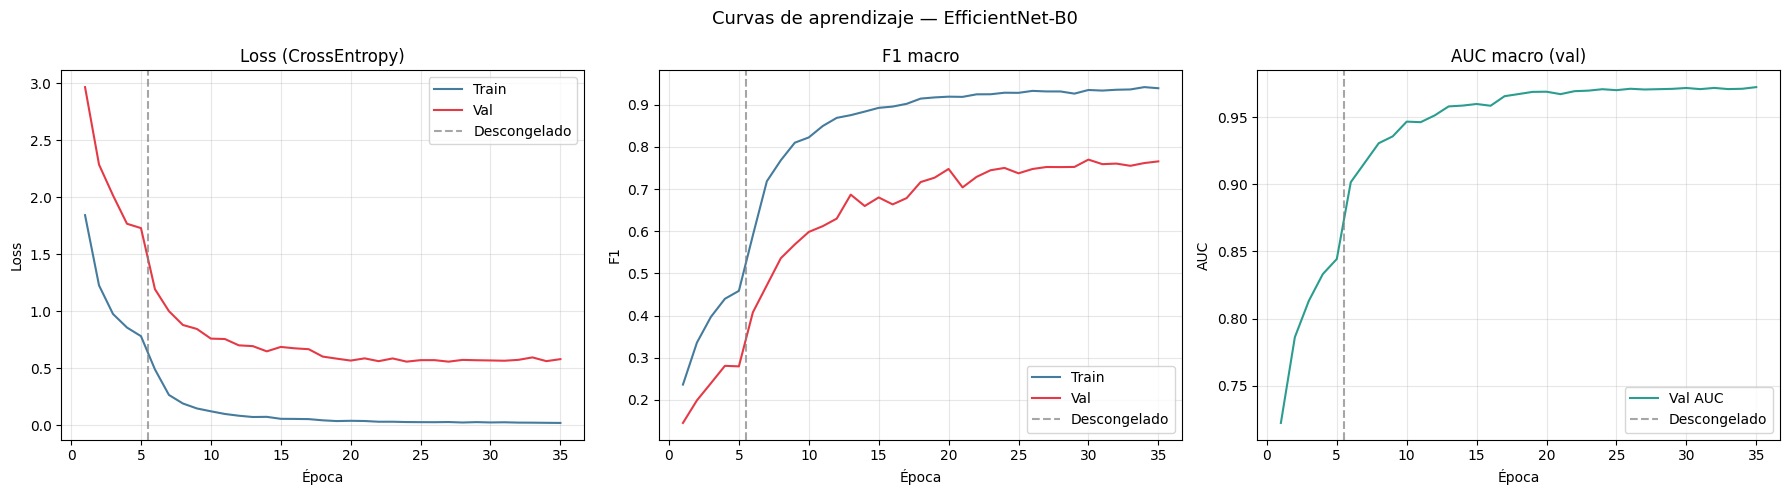

In [22]:
# Visualización de la evolución de loss y F1 durante el entrenamiento
# La línea vertical separa la fase congelada de la descongelada
epocas      = range(1, len(historial["train_loss"]) + 1)
n_frozen    = historial["fase"].count("frozen")

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Loss
axes[0].plot(epocas, historial["train_loss"], label="Train", color="#457b9d")
axes[0].plot(epocas, historial["val_loss"],   label="Val",   color="#e63946")
axes[0].axvline(x=n_frozen + 0.5, color="gray", linestyle="--", alpha=0.7, label="Descongelado")
axes[0].set_title("Loss (CrossEntropy)")
axes[0].set_xlabel("Época")
axes[0].set_ylabel("Loss")
axes[0].legend()
axes[0].grid(alpha=0.3)

# F1 macro
axes[1].plot(epocas, historial["train_f1"], label="Train", color="#457b9d")
axes[1].plot(epocas, historial["val_f1"],   label="Val",   color="#e63946")
axes[1].axvline(x=n_frozen + 0.5, color="gray", linestyle="--", alpha=0.7, label="Descongelado")
axes[1].set_title("F1 macro")
axes[1].set_xlabel("Época")
axes[1].set_ylabel("F1")
axes[1].legend()
axes[1].grid(alpha=0.3)

# AUC macro
axes[2].plot(epocas, historial["val_auc"], label="Val AUC", color="#2a9d8f")
axes[2].axvline(x=n_frozen + 0.5, color="gray", linestyle="--", alpha=0.7, label="Descongelado")
axes[2].set_title("AUC macro (val)")
axes[2].set_xlabel("Época")
axes[2].set_ylabel("AUC")
axes[2].legend()
axes[2].grid(alpha=0.3)

plt.suptitle("Curvas de aprendizaje — EfficientNet-B0", fontsize=13)
plt.tight_layout()
plt.savefig(DIR_OUTPUT / "curvas_clasificacion.png", dpi=150, bbox_inches="tight")
plt.show()

## 11. Evaluación final

In [23]:
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    roc_auc_score,
    roc_curve,
    f1_score,
)
from sklearn.preprocessing import label_binarize

# Cargar el mejor modelo guardado durante el entrenamiento
model.load_state_dict(torch.load(ruta_mejor_modelo, map_location=DEVICE))
model.eval()

# Recolectar predicciones completas sobre el set de validación
all_preds, all_labels, all_probs = [], [], []

with torch.no_grad():
    for imgs, labels in dl_val:
        imgs, labels = imgs.to(DEVICE), labels.to(DEVICE)
        logits = model(imgs)
        probs  = torch.softmax(logits, dim=1)

        all_preds.extend(logits.argmax(dim=1).cpu().numpy())
        all_labels.extend(labels.cpu().numpy())
        all_probs.extend(probs.cpu().numpy())

all_preds  = np.array(all_preds)
all_labels = np.array(all_labels)
all_probs  = np.array(all_probs)

# Métricas globales
f1_macro  = f1_score(all_labels, all_preds, average="macro",    zero_division=0)
f1_weight = f1_score(all_labels, all_preds, average="weighted", zero_division=0)
auc_macro = roc_auc_score(all_labels, all_probs, multi_class="ovr", average="macro")

print("=" * 55)
print("EVALUACIÓN FINAL — MEJOR MODELO")
print("=" * 55)
print(f"  F1 macro   : {f1_macro:.4f}")
print(f"  F1 weighted: {f1_weight:.4f}")
print(f"  AUC macro  : {auc_macro:.4f}")
print("=" * 55)

EVALUACIÓN FINAL — MEJOR MODELO
  F1 macro   : 0.7700
  F1 weighted: 0.7877
  AUC macro  : 0.9719


In [24]:
# Informe detallado por clase
nombres = [f"{c} ({NOMBRES_CLASES[c]})" for c in CLASES]
print(classification_report(
    all_labels, all_preds,
    target_names=nombres,
    zero_division=0,
))

                            precision    recall  f1-score   support

            MEL (Melanoma)       0.40      0.82      0.54       223
    NV (Melanocytic nevus)       0.98      0.73      0.84      1341
BCC (Basal cell carcinoma)       0.77      0.92      0.84       103
 AKIEC (Actinic keratosis)       0.71      0.74      0.72        65
    BKL (Benign keratosis)       0.62      0.82      0.71       220
       DF (Dermatofibroma)       0.81      0.91      0.86        23
    VASC (Vascular lesion)       0.82      0.96      0.89        28

                  accuracy                           0.77      2003
                 macro avg       0.73      0.84      0.77      2003
              weighted avg       0.85      0.77      0.79      2003



## 12. Matriz de confusión

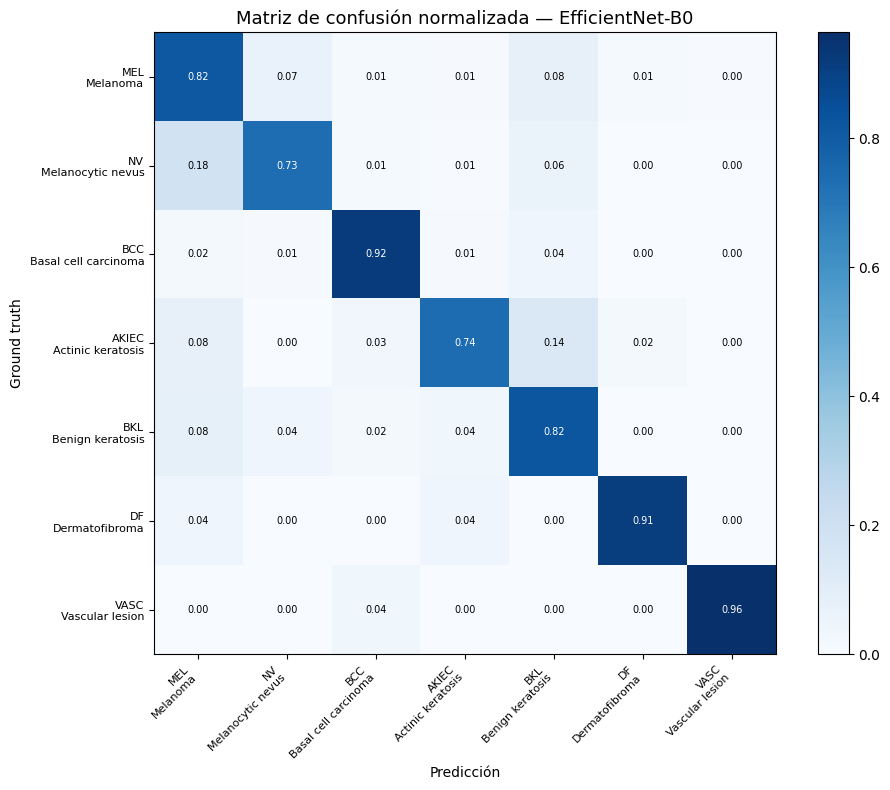

In [25]:
# Matriz de confusión normalizada por fila — muestra la tasa de acierto
# por clase independientemente del tamaño de cada clase
cm = confusion_matrix(all_labels, all_preds, normalize="true")

fig, ax = plt.subplots(figsize=(10, 8))
im = ax.imshow(cm, interpolation="nearest", cmap="Blues")
plt.colorbar(im, ax=ax)

etiquetas = [f"{c}\n{NOMBRES_CLASES[c]}" for c in CLASES]
ax.set_xticks(range(CFG["num_classes"]))
ax.set_yticks(range(CFG["num_classes"]))
ax.set_xticklabels(etiquetas, rotation=45, ha="right", fontsize=8)
ax.set_yticklabels(etiquetas, fontsize=8)

# Anotar cada celda con el valor
for i in range(CFG["num_classes"]):
    for j in range(CFG["num_classes"]):
        ax.text(j, i, f"{cm[i, j]:.2f}",
                ha="center", va="center",
                color="white" if cm[i, j] > 0.5 else "black",
                fontsize=7)

ax.set_xlabel("Predicción")
ax.set_ylabel("Ground truth")
ax.set_title("Matriz de confusión normalizada — EfficientNet-B0", fontsize=13)

plt.tight_layout()
plt.savefig(DIR_OUTPUT / "matriz_confusion.png", dpi=150, bbox_inches="tight")
plt.show()

## 13. Curvas ROC por clase

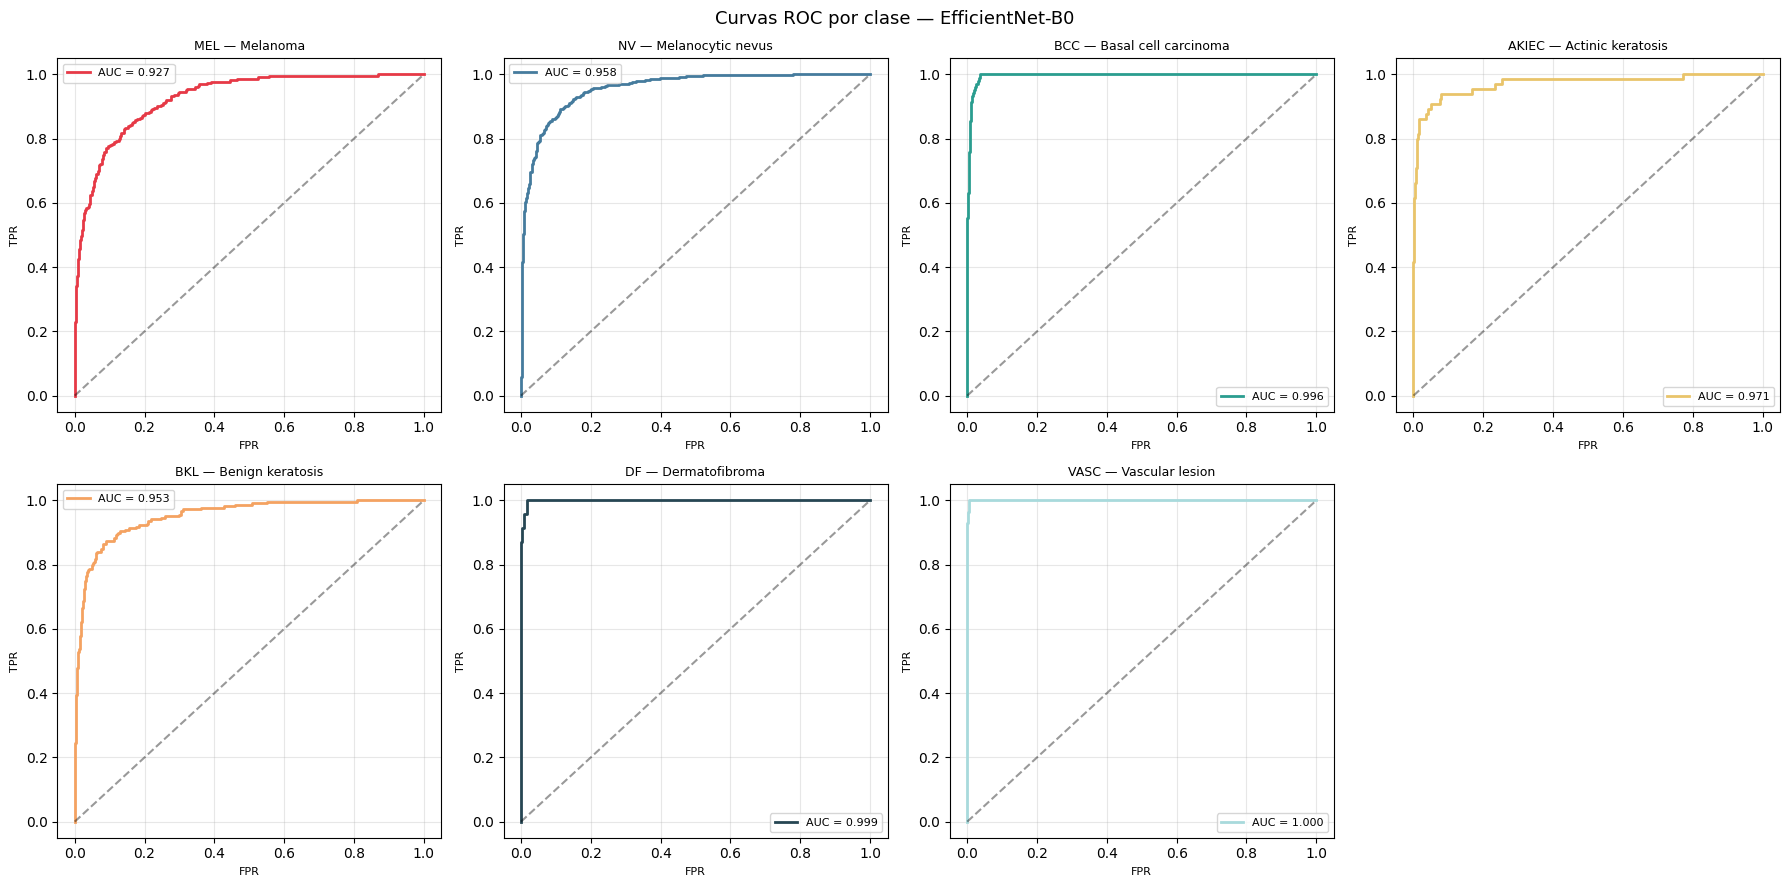

In [26]:
# Curvas ROC one-vs-rest para cada una de las 7 clases
# Permite identificar en qué categorías el modelo tiene mayor dificultad
labels_bin = label_binarize(all_labels, classes=list(range(CFG["num_classes"])))

fig, axes = plt.subplots(2, 4, figsize=(18, 9))
axes = axes.flatten()

colores = ["#e63946", "#457b9d", "#2a9d8f", "#e9c46a", "#f4a261", "#264653", "#a8dadc"]

for i, (clase, color) in enumerate(zip(CLASES, colores)):
    fpr, tpr, _ = roc_curve(labels_bin[:, i], all_probs[:, i])
    auc_clase   = roc_auc_score(labels_bin[:, i], all_probs[:, i])

    axes[i].plot(fpr, tpr, color=color, lw=2,
                 label=f"AUC = {auc_clase:.3f}")
    axes[i].plot([0, 1], [0, 1], "k--", alpha=0.4)
    axes[i].set_title(f"{clase} — {NOMBRES_CLASES[clase]}", fontsize=9)
    axes[i].set_xlabel("FPR", fontsize=8)
    axes[i].set_ylabel("TPR", fontsize=8)
    axes[i].legend(fontsize=8)
    axes[i].grid(alpha=0.3)

# Ocultar el último subplot vacío
axes[-1].set_visible(False)

plt.suptitle("Curvas ROC por clase — EfficientNet-B0", fontsize=13)
plt.tight_layout()
plt.savefig(DIR_OUTPUT / "curvas_roc.png", dpi=150, bbox_inches="tight")
plt.show()

## 14. Visualización de predicciones

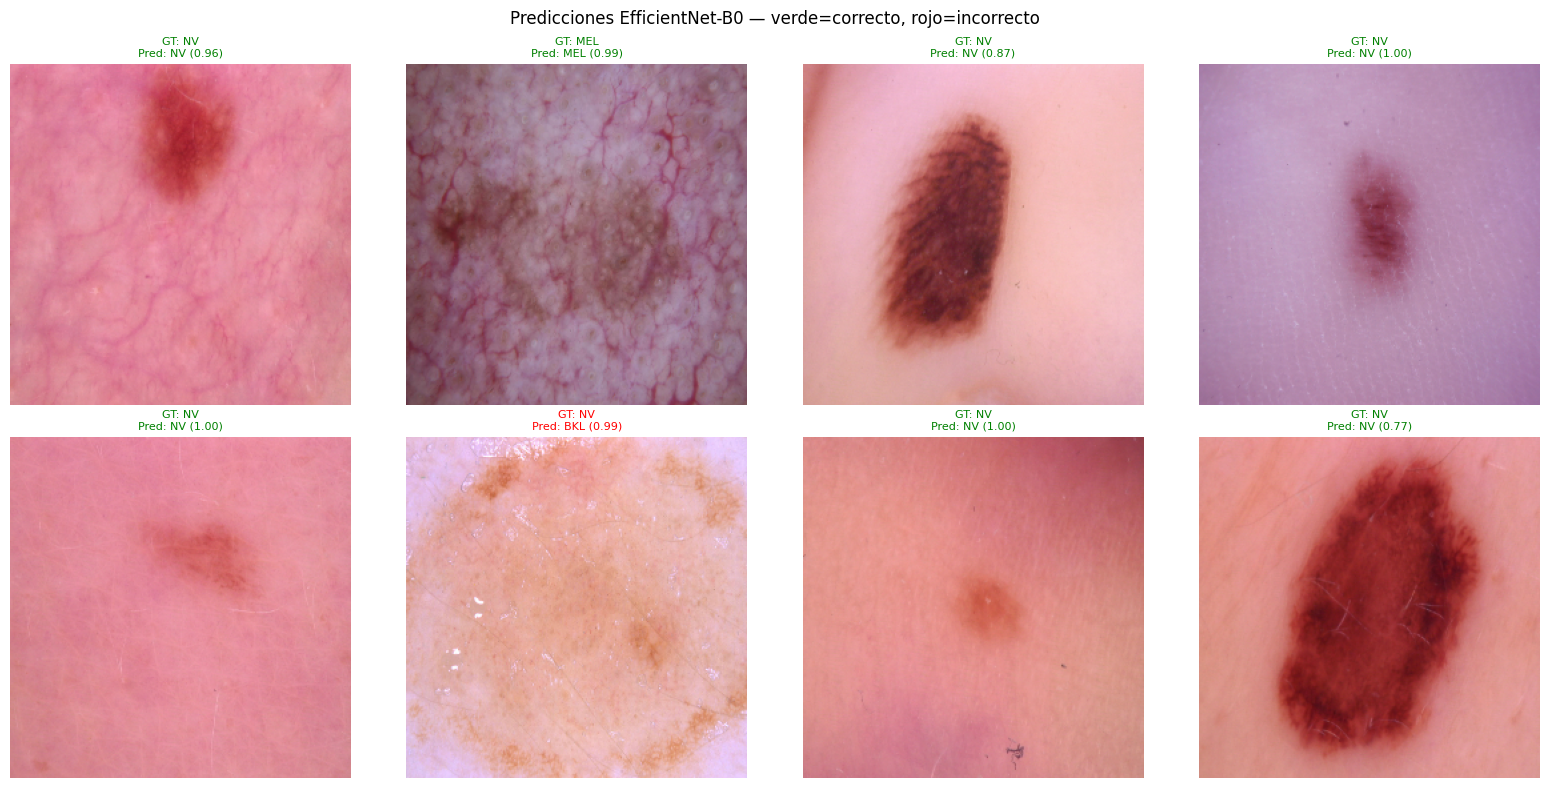

In [27]:
# Visualización de 8 predicciones aleatorias del mejor modelo
# Verde = predicción correcta, Rojo = predicción incorrecta
MEAN = np.array([0.485, 0.456, 0.406])
STD  = np.array([0.229, 0.224, 0.225])

random.seed(0)
indices_viz = random.sample(list(range(len(ds_val))), 8)

fig, axes = plt.subplots(2, 4, figsize=(16, 8))
axes = axes.flatten()

model.eval()
with torch.no_grad():
    for i, idx in enumerate(indices_viz):
        img_t, label = ds_val[idx]

        logits = model(img_t.unsqueeze(0).to(DEVICE))
        pred   = logits.argmax(dim=1).item()
        prob   = torch.softmax(logits, dim=1).max().item()

        # Desnormalizar imagen para visualización
        img_np = img_t.permute(1, 2, 0).numpy()
        img_np = np.clip(img_np * STD + MEAN, 0, 1)

        color_titulo = "green" if pred == label.item() else "red"

        axes[i].imshow(img_np)
        axes[i].set_title(
            f"GT: {CLASES[label.item()]}\nPred: {CLASES[pred]} ({prob:.2f})",
            fontsize=8,
            color=color_titulo,
        )
        axes[i].axis("off")

plt.suptitle("Predicciones EfficientNet-B0 — verde=correcto, rojo=incorrecto",
             fontsize=12)
plt.tight_layout()
plt.savefig(DIR_OUTPUT / "predicciones_clasificacion.png", dpi=150, bbox_inches="tight")
plt.show()

## 15. Publicación del modelo en HF Hub

In [28]:
from huggingface_hub import HfApi
from kaggle_secrets import UserSecretsClient

HF_TOKEN = UserSecretsClient().get_secret("HF_TOKEN")
HF_REPO  = "Jesusrodriguezf90/efficientnet-b0-isic2018-classification"

api = HfApi()

# Crear el repositorio si no existe
api.create_repo(repo_id=HF_REPO, token=HF_TOKEN, exist_ok=True)

# Subir el modelo
api.upload_file(
    path_or_fileobj = str(ruta_mejor_modelo),
    path_in_repo    = "best_efficientnet_b0.pth",
    repo_id         = HF_REPO,
    token           = HF_TOKEN,
)

print(f"Modelo publicado en: https://huggingface.co/{HF_REPO}")

Processing Files (0 / 0): |          |  0.00B /  0.00B            

New Data Upload: |          |  0.00B /  0.00B            

Modelo publicado en: https://huggingface.co/Jesusrodriguezf90/efficientnet-b0-isic2018-classification


## 16. Resumen

In [29]:
# Resumen del experimento
print("=" * 60)
print("RESUMEN — CLASIFICACIÓN EfficientNet-B0")
print("=" * 60)
print(f"  Resolución entrada    : {CFG['img_size']}×{CFG['img_size']}")
print(f"  Imágenes entrenamiento: {len(df_train)}")
print(f"  Imágenes validación   : {len(df_val)}")
print(f"  Épocas ejecutadas     : {len(historial['train_loss'])}")
print(f"  Mejor F1 macro val    : {mejor_f1:.4f}")
print(f"  F1 macro final        : {f1_macro:.4f}")
print(f"  AUC macro final       : {auc_macro:.4f}")
print(f"  Modelo en HF Hub      : {HF_REPO}")
print("=" * 60)
print("Siguiente paso: 04_evaluation.ipynb")

RESUMEN — CLASIFICACIÓN EfficientNet-B0
  Resolución entrada    : 256×256
  Imágenes entrenamiento: 8012
  Imágenes validación   : 2003
  Épocas ejecutadas     : 35
  Mejor F1 macro val    : 0.7700
  F1 macro final        : 0.7700
  AUC macro final       : 0.9719
  Modelo en HF Hub      : Jesusrodriguezf90/efficientnet-b0-isic2018-classification
Siguiente paso: 04_evaluation.ipynb
